In [27]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
path = r"..\Data\cleaned_customer.csv"
df1 = pd.read_csv(path)
df1['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [7]:
NOW = dt.datetime(2011,12,10)

In [10]:
rfmTable = df1.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (NOW - x.max()).days,
    'InvoiceNo': lambda x: len(x),
    'TotalPrice': lambda x: x.sum()
})

rfmTable.rename(columns={
    'InvoiceDate': 'recency',
    'InvoiceNo': 'frequency',
    'TotalPrice': 'monetary_value'
}, inplace=True)

In [11]:
rfmTable

,recency,frequency,monetary_value
CustomerID,,,
12346.0,325,2,0.00
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,18,73,1757.55
12350.0,310,17,334.40
...,...,...,...
18280.0,277,10,180.60
18281.0,180,7,80.82
18282.0,7,13,176.60


In [12]:
quantiles = rfmTable.quantile(q=[0.25,0.5,0.75])
quantiles = quantiles.to_dict()

In [13]:
quantiles

{'recency': {0.25: 16.0, 0.5: 50.0, 0.75: 143.0},
 'frequency': {0.25: 17.0, 0.5: 41.0, 0.75: 99.25},
 'monetary_value': {0.25: 291.795, 0.5: 644.0700000000002, 0.75: 1608.335}}

In [14]:
# Create a customer segment RFM table
segmented_rfm = rfmTable

In [15]:
def RScore(x,p,d):
    if x <= d[p][0.25]:
        return 1
    elif x <= d[p][0.50]:
        return 2
    elif x <= d[p][0.75]: 
        return 3
    else:
        return 4
    
def FMScore(x,p,d):
    if x <= d[p][0.25]:
        return 4
    elif x <= d[p][0.50]:
        return 3
    elif x <= d[p][0.75]: 
        return 2
    else:
        return 1

In [16]:
segmented_rfm['r_quartile'] = segmented_rfm['recency'].apply(RScore, args=('recency',quantiles,))
segmented_rfm['f_quartile'] = segmented_rfm['frequency'].apply(FMScore, args=('frequency',quantiles,))
segmented_rfm['m_quartile'] = segmented_rfm['monetary_value'].apply(FMScore, args=('monetary_value',quantiles,))

In [18]:
segmented_rfm

,recency,frequency,monetary_value,r_quartile,f_quartile,m_quartile,RFMScore
CustomerID,,,,,,,
12346.0,325,2,0.00,4,4,4,444
12347.0,2,182,4310.00,1,1,1,111
12348.0,75,31,1797.24,3,3,1,331
12349.0,18,73,1757.55,2,2,1,221
12350.0,310,17,334.40,4,4,3,443
...,...,...,...,...,...,...,...
18280.0,277,10,180.60,4,4,4,444
18281.0,180,7,80.82,4,4,4,444
18282.0,7,13,176.60,1,4,4,144


In [19]:
segmented_rfm['RFMScore'] = (
    segmented_rfm.r_quartile.map(str) + 
    segmented_rfm.f_quartile.map(str) + 
    segmented_rfm.m_quartile.map(str)
)

In [20]:
segmented_rfm

,recency,frequency,monetary_value,r_quartile,f_quartile,m_quartile,RFMScore
CustomerID,,,,,,,
12346.0,325,2,0.00,4,4,4,444
12347.0,2,182,4310.00,1,1,1,111
12348.0,75,31,1797.24,3,3,1,331
12349.0,18,73,1757.55,2,2,1,221
12350.0,310,17,334.40,4,4,3,443
...,...,...,...,...,...,...,...
18280.0,277,10,180.60,4,4,4,444
18281.0,180,7,80.82,4,4,4,444
18282.0,7,13,176.60,1,4,4,144


In [21]:
segmented_rfm[segmented_rfm['RFMScore']=='111'] \
    .sort_values('monetary_value', ascending=False) \
    .head(10)

,recency,frequency,monetary_value,r_quartile,f_quartile,m_quartile,RFMScore
CustomerID,,,,,,,
14646.0,1,2085,279489.02,1,1,1,111
18102.0,0,433,256438.49,1,1,1,111
17450.0,8,350,187322.17,1,1,1,111
14911.0,1,5898,132458.73,1,1,1,111
14156.0,9,1415,113214.59,1,1,1,111
17511.0,2,1076,88125.38,1,1,1,111
16684.0,4,281,65892.08,1,1,1,111
13694.0,3,584,62690.54,1,1,1,111
15311.0,0,2478,59284.19,1,1,1,111


In [22]:
def segment_customer(row):
    if row['RFMScore'] == '111':
        return 'Champions'
    
    elif row['r_quartile'] <= 2 and row['f_quartile'] <= 2:
        return 'Loyal Customers'
    
    elif row['r_quartile'] == 1:
        return 'Recent Customers'
    
    elif row['r_quartile'] >= 3 and row['f_quartile'] <= 2:
        return 'At Risk'
    
    elif row['r_quartile'] == 4:
        return 'Lost Customers'
    
    else:
        return 'Others'

segmented_rfm['Segment'] = segmented_rfm.apply(segment_customer, axis=1)

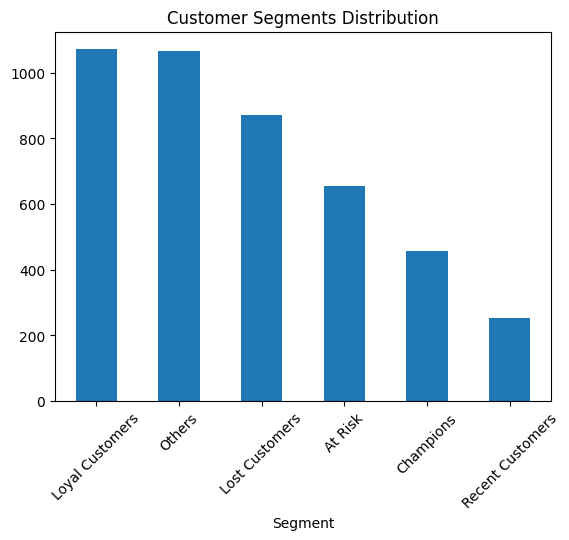

In [26]:
segmented_rfm['Segment'].value_counts().plot(kind='bar')
plt.title('Customer Segments Distribution')
plt.xticks(rotation=45)
plt.show()

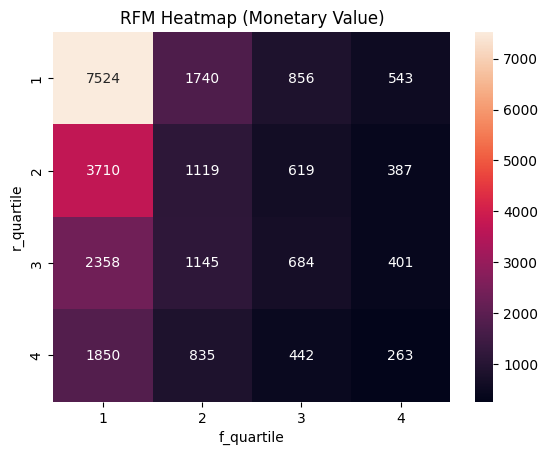

In [28]:
pivot = segmented_rfm.pivot_table(
    index='r_quartile',
    columns='f_quartile',
    values='monetary_value',
    aggfunc='mean'
)

sns.heatmap(pivot, annot=True, fmt=".0f")
plt.title('RFM Heatmap (Monetary Value)')
plt.show()

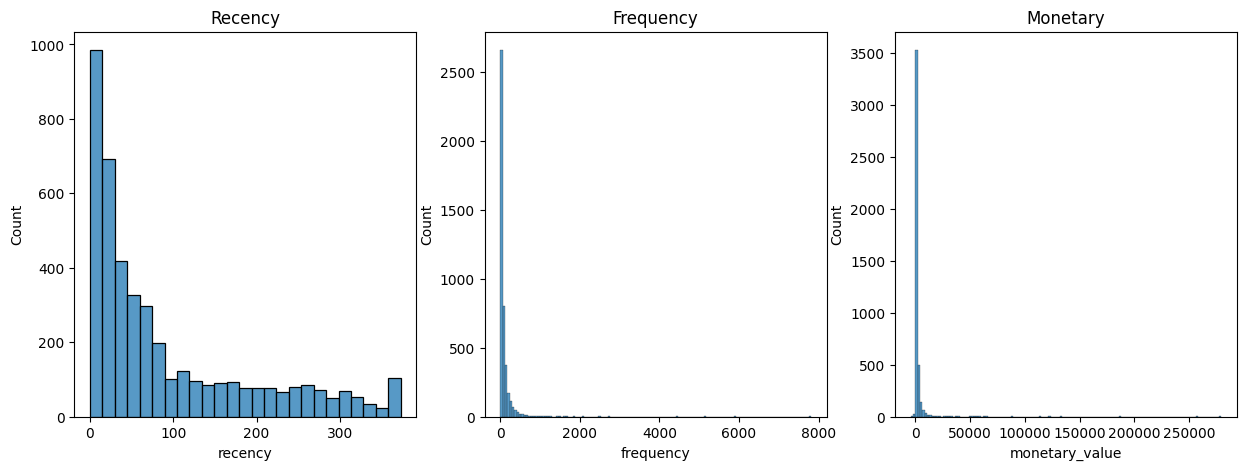

In [29]:
fig, ax = plt.subplots(1,3, figsize=(15,5))

sns.histplot(segmented_rfm['recency'], ax=ax[0])
sns.histplot(segmented_rfm['frequency'], ax=ax[1])
sns.histplot(segmented_rfm['monetary_value'], ax=ax[2])

ax[0].set_title('Recency')
ax[1].set_title('Frequency')
ax[2].set_title('Monetary')

plt.show()

In [30]:
segmented_rfm.head()

,recency,frequency,monetary_value,r_quartile,f_quartile,m_quartile,RFMScore,Segment
CustomerID,,,,,,,,
12346.0,325,2,0.00,4,4,4,444,Lost Customers
12347.0,2,182,4310.00,1,1,1,111,Champions
12348.0,75,31,1797.24,3,3,1,331,Others
12349.0,18,73,1757.55,2,2,1,221,Loyal Customers
12350.0,310,17,334.40,4,4,3,443,Lost Customers


In [31]:
df_final = df1.merge(segmented_rfm, on='CustomerID', how='left')

In [32]:
df_final.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,recency,frequency,monetary_value,r_quartile,f_quartile,m_quartile,RFMScore,Segment
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,302,309,5303.48,4,1,1,411,At Risk
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,302,309,5303.48,4,1,1,411,At Risk
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,302,309,5303.48,4,1,1,411,At Risk
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,302,309,5303.48,4,1,1,411,At Risk
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,302,309,5303.48,4,1,1,411,At Risk


In [33]:
segmented_rfm['recency'].describe()

count    4372.000000
mean       91.581199
std       100.772139
min         0.000000
25%        16.000000
50%        50.000000
75%       143.000000
max       373.000000
Name: recency, dtype: float64

In [35]:
save_path = r"..\Data\cleaned_customer_with_rfm.csv"
df_final.to_csv(save_path, index = False)